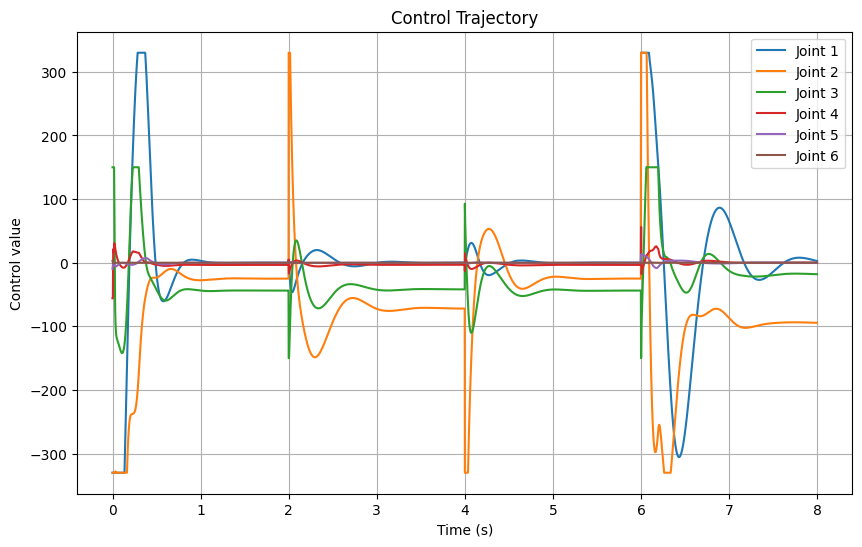

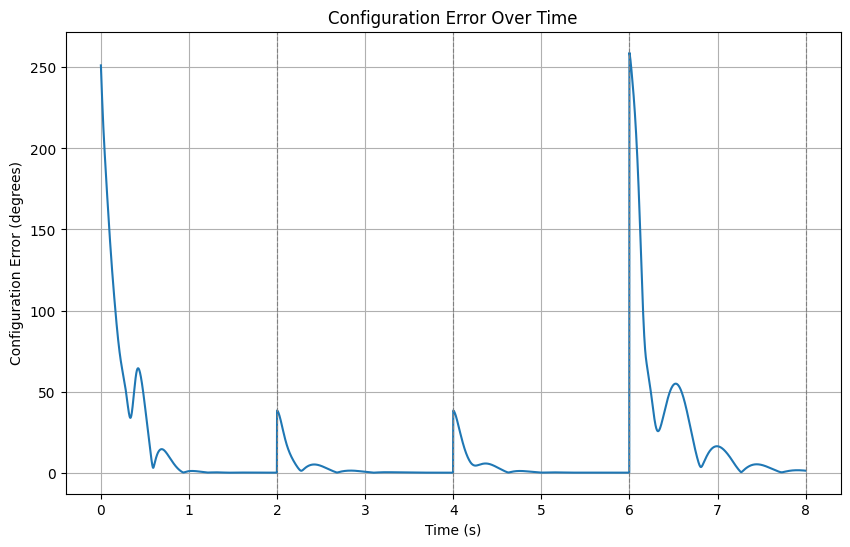

In [ ]:
from optimal.RobotController import RobotController
from optimal.RobotMujocoModel import RobotMujocoModel
from optimal.RobotPinocchioModel import RobotPinocchioModel
from optimal.configuration import UR10, UR10_sandbox
import pinocchio as pin
import numpy as np
import mujoco

type = UR10_sandbox
robot_mj_model = RobotMujocoModel(type.mjcf_path, type.list_of_joints)
robot_pin_model = RobotPinocchioModel(type.urdf_path, type.list_of_joints)

DT = robot_mj_model.model.opt.timestep
path = [robot_pin_model.current_q(),
     np.array([-1.8, -1.8, 1.8, -1.8, -1.8, 1.8]),
     np.array([-1.8, -1.2, 1.5, -1.8, -1.8, 1.8]),
     np.array([-1.8, -1.8, 1.8, -1.8, -1.8, 1.8]),
     np.array([0.4, -0.4, 1.5, -0.8, 1.5, 0.5])]

controller = RobotController(robot_pin_model)
xs, us = [], []
v_start = np.zeros(len(robot_pin_model.v_indices))
for i in range(len(path) - 1):
    start = np.concatenate([path[i], v_start])
    target = np.concatenate([path[i+1], np.zeros(len(robot_pin_model.v_indices))])
    t_xs, t_us = controller.compute_control(x_start=start, 
                                            x_goal=target, 
                                            T=1000, DT=DT, kp=type.kp, kd=type.kd,
                                            option="pd")
    xs.extend(t_xs)
    us.extend(t_us)
    v_start = xs[-1][len(robot_pin_model.q_indices):]

# robot_mj_model.visualize("position", xs=xs, dt=DT, hold=False)
# robot_mj_model.reset()
# xs_real, us_real = robot_mj_model.visualize("control", us=us, dt=DT, hold=False)
# robot_mj_model.plot_error(xs_real, path[1:], segment_lengths=[1000]*len(path), dt=DT)
# robot_mj_model.reset()
xs_real, us_real = robot_mj_model.visualize("control", us=us, xs=xs, kp=type.kp, kd=type.kd, dt=DT, hold=False, plot=True)
# xs_real, us_real = robot_mj_model.simulate_control(us=us, xs=xs, kp=type.kp, kd=type.kd)
# xs_real, us_real = robot_mj_model.simulate_control(us=us)
# robot_mj_model.plot_controls(us, dt=DT)
robot_mj_model.plot_controls(us_real, dt=DT)
robot_mj_model.plot_error(xs_real, path[1:], segment_lengths=[1000]*len(path), dt=DT)


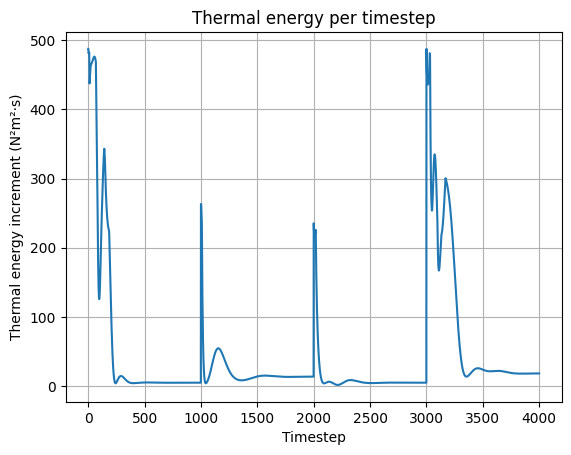

Thermal energy: 195024.39491394957


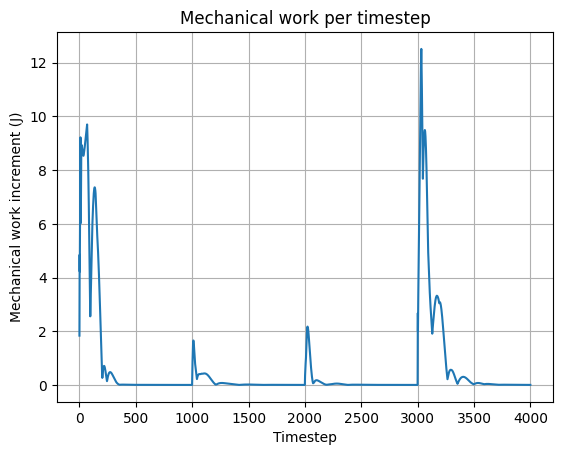

Mechanical work: 2785.9345606446063


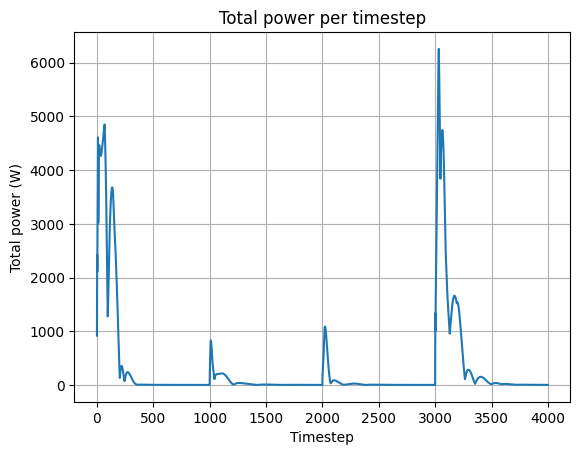

Peak power: 6257.174450083941


In [16]:
from optimal.metrics import thermal_energy, mechanical_work, peak_power

E_th  = thermal_energy(us_real, DT, True)
print("Thermal energy:", E_th)
E_mech = mechanical_work(us_real, xs_real, DT, True)
print("Mechanical work:", E_mech)
P_peak = peak_power(us_real, xs_real, True)
print("Peak power:", P_peak)

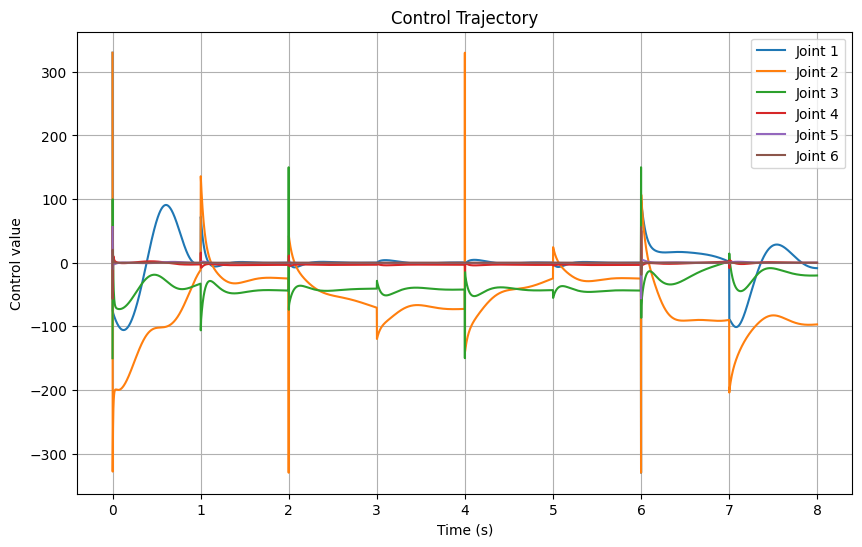

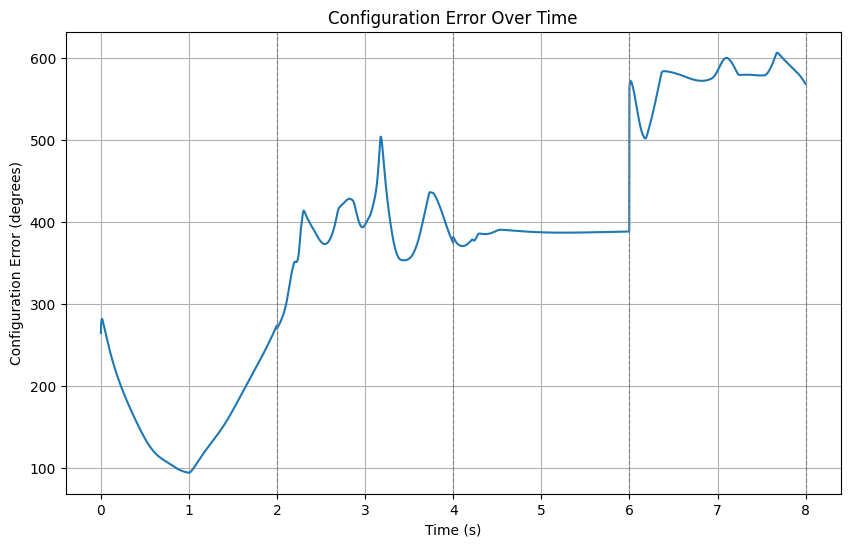

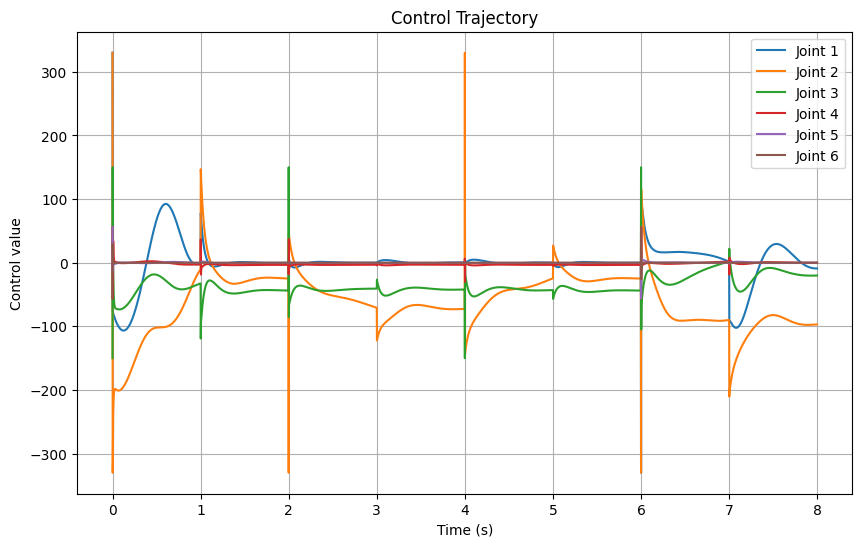

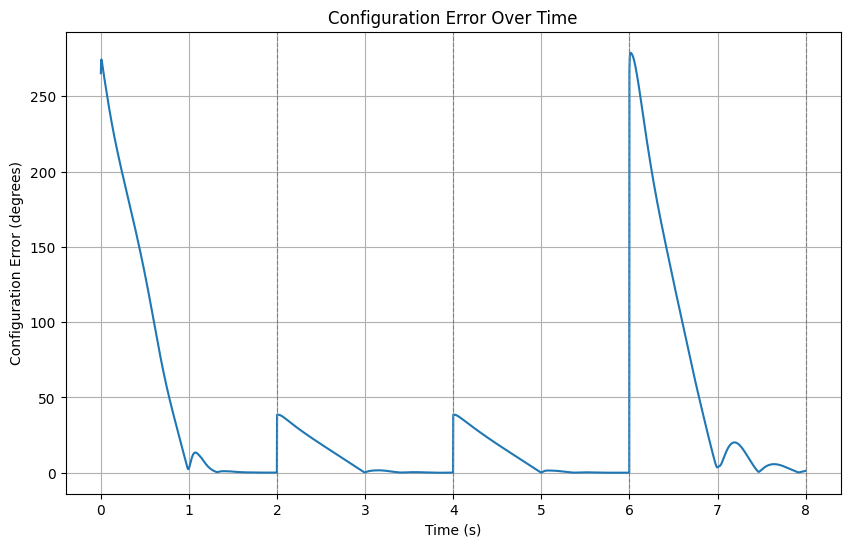

In [12]:
xs, us = [], []
for i in range(len(path) - 1):
    start = np.concatenate([path[i], np.zeros(len(robot_pin_model.v_indices))])
    target = np.concatenate([path[i+1], np.zeros(len(robot_pin_model.v_indices))])
    t_xs, t_us = controller.compute_control(x_start=start, 
                                            x_goal=target, 
                                            T=1000, DT=DT, kp=type.kp, kd=type.kd,
                                            alpha=0.5,
                                            option="pd")
    xs.extend(t_xs)
    us.extend(t_us)
robot_mj_model.reset()
xs_real, us_real = robot_mj_model.visualize(mode="control", us=us, dt=DT, hold=False)
robot_mj_model.plot_controls(us_real, dt=DT)
robot_mj_model.plot_error(xs_real, path[1:], segment_lengths=[1000]*len(path), dt=DT)
robot_mj_model.reset()
xs_real, us_real = robot_mj_model.visualize("control", us=us, xs=xs, kp=type.kp, kd=type.kd, dt=DT, hold=False)
robot_mj_model.plot_controls(us_real, dt=DT)
robot_mj_model.plot_error(xs_real, path[1:], segment_lengths=[1000]*len(path), dt=DT)


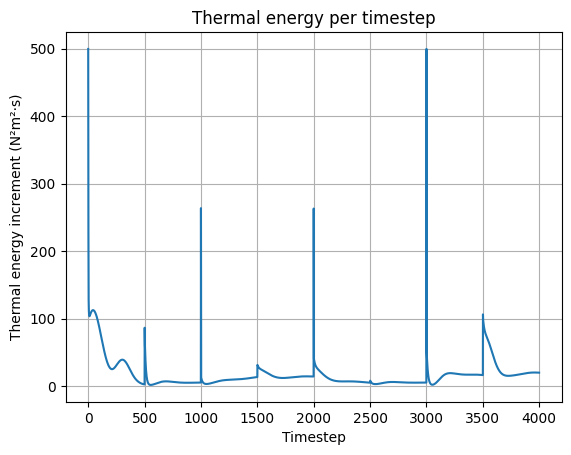

Thermal energy: 68847.23133103385


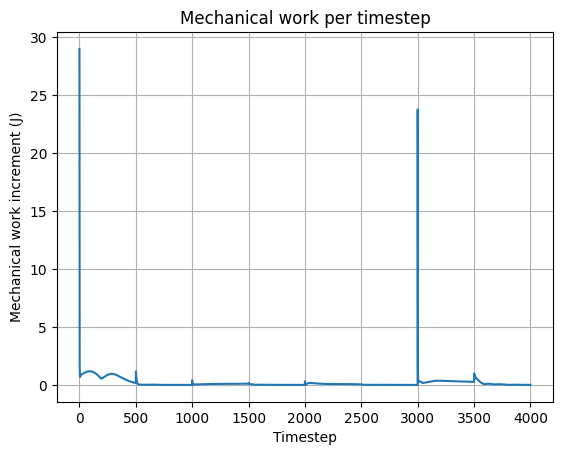

Mechanical work: 756.945618000458


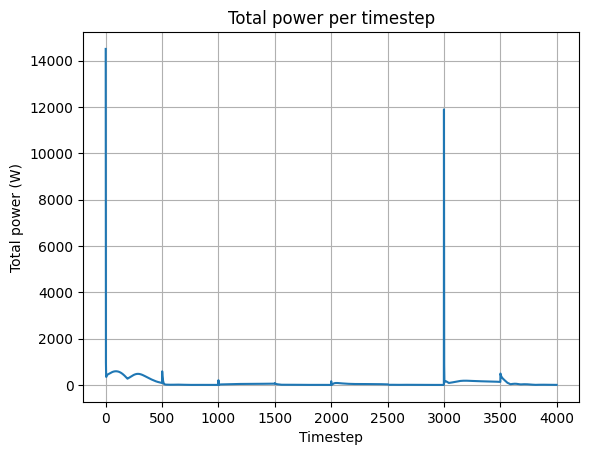

Peak power: 14501.008318085058


In [13]:
E_th  = thermal_energy(us_real, DT, True)
print("Thermal energy:", E_th)
E_mech = mechanical_work(us_real, xs_real, DT, True)
print("Mechanical work:", E_mech)
P_peak = peak_power(us_real, xs_real, True)
print("Peak power:", P_peak)